# Quantifying Sales Uplift With Causal Impact Analysis

In this project we use Causal Impact Analysis to analyse & understand the sales uplift of customers that joined the new “Delivery Club” campaign!.

## Project Overview

### Context
Earlier in the year, our client, a grocery retailer, ran a campaign to promote their new “Delivery Club” - an initiative that costs a customer 100 USD per year for membership, but offers free grocery deliveries rather than the normal cost of 10 USD per delivery.

They want to understand if customers who did join the club have increased their spend in the three months following. The hypothesis is that, if customers are not paying for deliveries, they will be tempted to shop more frequently, and hopefully purchase more each time.

The aim of this work is to understand and quantify the uplift in sales for customers that joined the club, over and above what they would have spent had the club not come into existence!

### Actions
We applied Causal Impact Analysis (see full details below) using the pycausalimpact library.

In the client database, we have a campaign_data table which shows us which customers received each type of “Delivery Club” mailer, which customers were in the control group, and which customers joined the club as a result.

Since Delivery Club membership was open to all customers - the control group we have in the campaign_data table would help us measure the impact of contacting customers but here, we are actually look to measure the overall impact on sales from the Delivery Club itself. Because of this, we instead used customers who did not sign up as the control. The hypothesis was that customers who did not sign up should continue their normal shopping habits after the club went live, and this will help us create the counter-factual for the customers that did sign-up.

Sales data was from the transactions table and was aggregated from a customer/transaction/product area level to customer/date level as per the requirements of the algorithm.

We used a 3 months pre-period for the algorithm to model, 3 months post-period for the counterfactual.

## Causal Impact Analysis Overview

### Context
One of the most common tasks we undertake in Data Science & Data Analysis is understanding and quantifying a change in a key business metric after some event has taken place.

Depending on the industry - this could be the uplift in sales after a promotion or a product release, the additional clicks, conversions, or signups generated by an online ad campaign, the change in share price after a market event, or even the change in the value of the US dollar after the president opens his mouth.

Whatever the scenario, the task is essentially the same - we want to understand how big this change was.

But to understand this robustly & reliably we really need to understand what would have happened had the event not taken place.

In most cases the trends preceding the event in question isn’t tame, it is filled with lumps and bumps and ups and downs. When some key event does take place, understanding what would have happened had the event not taken place so we can estimate the true impact can be difficult!

In many cases, the event that we’re analysing is part of a randomised & controlled experiment, and this means understanding the difference between the group that was affected by the event can be compared to a control group, that was purposely held back from the effect of the event.

But there are a lot of cases where we just can’t run a randomised experiment, either because it’s expensive, or potentially it’s just impossible. As an example, in the case of measuring the change in a share price after an event, we don’t really have a direct control group to lean on for comparison purposes.

An approach that works really well in both scenarios, is Causal Impact Analysis.



### How It Works
Causal Impact is a time-series technique, originally developed by Google.

It estimates what would have happened (known as a “counterfactual”) by applying a model to comparable data in a pre-period and projecting this model onto that data in a post-period. The difference between the actual data and the counterfactual in the post-period, is the estimated impact of the event.

The comparable data that we pass in can be a control group, another set of related data, or even multiple sets of related data - but for this approach to work robustly & reliably, this additional data must must adhere to several rules:

It must not be affected by the event that we’re measuring, but it must be predictive of our output, or have some relationship with our initial time-series data.

So, in the case of randomised experiment, we could use the control group as our additional set of data.

In the case where we don’t have a control group, we need to find other sets of data that meet the aforementoined rules. These must not be affected by the event, but they should have some relationship or correlation with the time-series data we’re measuring. If we were measuring stock prices, perhaps we could use other stocks that are in a similar industry to us. If we were measuring the sales of a certain section of the grocery store, say health and beauty products, perhaps our second time-series could be the sales of another non-food category in the store.

Either way, this additional data provides the algorithm insights into the trends of the data over time.

The algorithm uses these insights to models the relationship between the two (or more) time-series in the pre-period. In other words, it finds a set of rules that best predict the time-series of interest, based on the movements and fluctuations of the other time-series that we provided it.

Once the algorithm has modelled this relationship, it then looks to apply the learnings from this model in the post-period, the result of which is an estimation for the counterfactual, or what the model believes would have happened to our time series if our event never took place!

Once we have this counterfactual, we can proceed to calculate the estimation for the causal effect, or in other words, the effect caused by our event!



### Application
Here we will utilise a Python package called pycausalimpact to apply this algorithm to our data. This will model the relationships, and provide very useful plots and summarises to help us understand the results.

## Data Overview & Preparation

In the client database, we have a campaign_data table which shows us which customers received each type of “Delivery Club” mailer, which customers were in the control group, and which customers joined the club as a result.

Since Delivery Club membership was open to all customers - the control group we have in the campaign_data table would help us measure the impact of contacting customers but here, we are actually look to measure the overall impact on sales from the Delivery Club itself. Because of this, we will instead just use customers who did not sign up as the control. The customers who did not sign up should continue their normal shopping habits after the club went live, and this will help us create the counter-factual for the customers that did sign-up.

In the code below, we:

- Load in the Python libraries we require
- Import the required data from the transactions and campaign_data tables (3 months prior, 3 months post campaign)
- Aggregate the transactions table from customer/transaction/product area level to customer/date level
- Merge on the signup flag from the campaign_data table
- Pivot & aggregate to give us aggregated daily sales by signed-up/did not sign-up groups
- Manoeuvre the data specifically for the pycausalimpact algorithm
- Give our groups some meaningful names, to help with interpretation

In [5]:
# install the required python libraries
from causalimpact import CausalImpact
import pandas as pd

# import data tables
transactions = pd.read_excel("data/grocery_database.xlsx", sheet_name= "transactions")
campaign_data = pd.read_excel("data/grocery_database.xlsx", sheet_name= "campaign_data")

# aggregate transaction data to customer, date level
customer_daily_sales = transactions.groupby(["customer_id", "transaction_date"])["sales_cost"].sum().reset_index()

# merge on the signup flag
customer_daily_sales = pd.merge(customer_daily_sales, campaign_data, how = "inner", on = "customer_id")

# pivot the data to aggregate daily sales by signup group
causal_impact_df = customer_daily_sales.pivot_table(index = "transaction_date",
                                                    columns = "signup_flag",
                                                    values = "sales_cost",
                                                    aggfunc = "mean")

# provide a frequency for our DateTimeIndex (avoids a warning message)
causal_impact_df.index.freq = "D"

# ensure the impacted group is in the first column (the library expects this)
causal_impact_df = causal_impact_df[[1,0]]

# rename columns to something lear & meaningful
causal_impact_df.columns = ["member", "non_member"]

causal_impact_df.head()

,member,non_member
transaction_date,,
2020-04-01,194.488065,74.463333
2020-04-02,185.161667,75.558254
2020-04-03,118.121333,74.387353
2020-04-04,198.525357,63.003797
2020-04-05,145.456000,72.440441


A sample of this data (the first 5 days of data) can be seen above.

In the DataFrame we have the transaction data, and then a column showing the average daily sales for those who signed up (member) and those who did not (non_member). This is the required format for applying the algorithm.

## Applying The Causal Impact Algorithm

In the code below, we specify the start and end dates of the “pre-period” and the start and end dates of the “post-period”. We then apply the algorithm by passing in the DataFrame and the specified pre and post period time windows.

The algorithm will model the relationship between members & non-members in the pre-period - and it will use this to create the counterfactual, in other words what it believes would happen to the average daily spend for members in the post-period if no event was to have taken place!

The difference between this counterfactual and the actual data in the post-period will be our “causal impact”

In [8]:
# specify the pre & post periods
pre_period = ["2020-04-01","2020-06-30"]
post_period = ["2020-07-01","2020-09-30"]

# apply the algorithm
ci = CausalImpact(causal_impact_df, pre_period, post_period)

C:\Users\haris\anaconda3\Lib\site-packages\causalimpact\main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
C:\Users\haris\anaconda3\Lib\site-packages\causalimpact\main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
C:\Users\haris\anaconda3\Lib\site-packages\statsmodels\base\optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: standardize, nseasons. After release 0.14, this will raise.
  warnings.warn(
C:\Users\haris\anaconda3\Li

## Analysing The Results

### Plotting The Results
The pycausalimpact library makes plotting the results extremely easy - all done with the single line of code below:

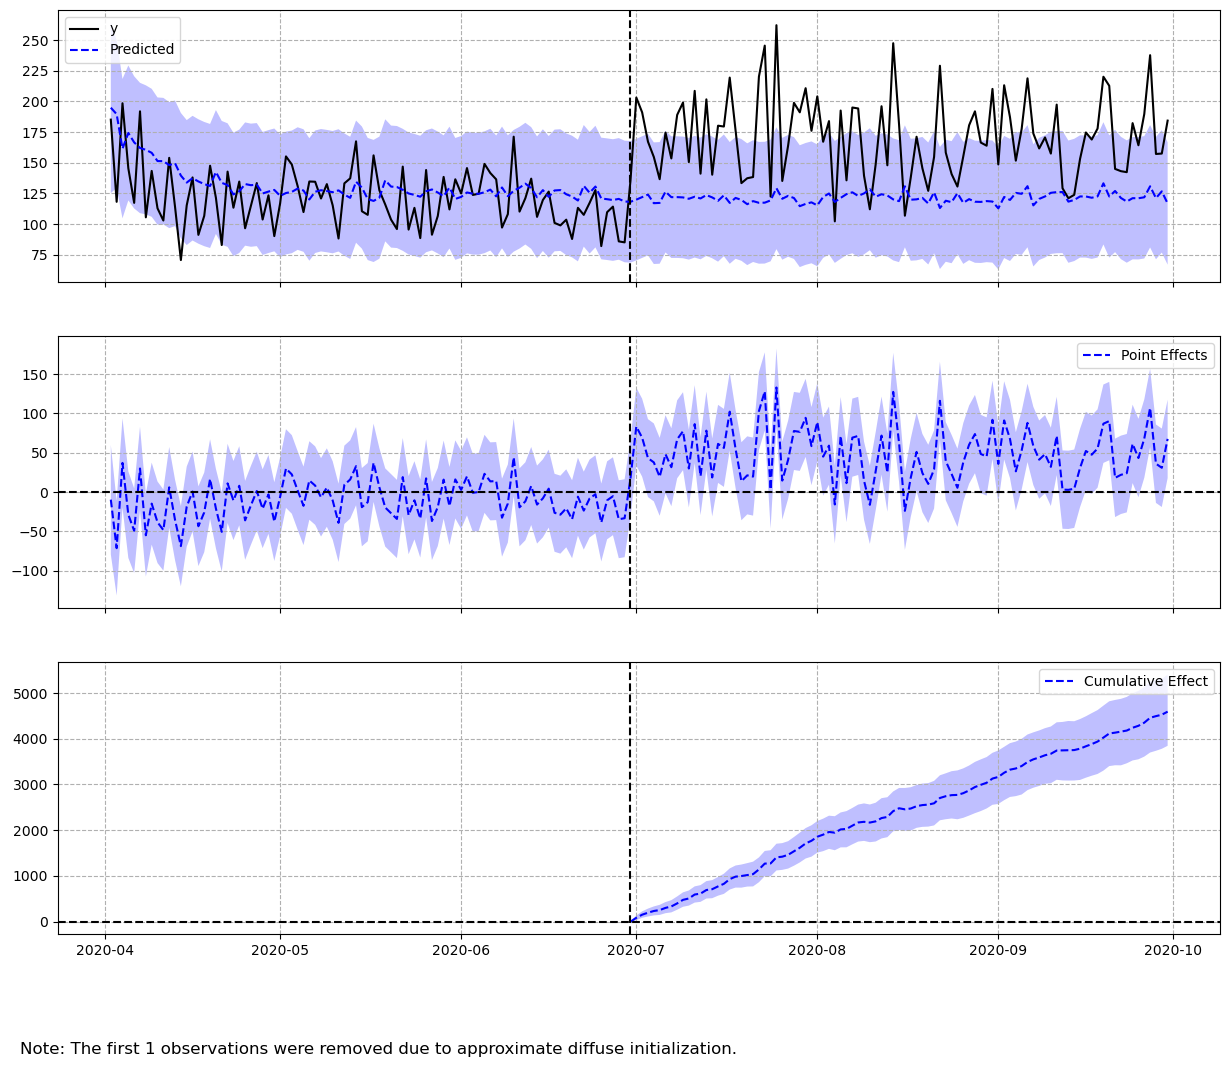

In [10]:
# plot the results
ci.plot()

#The resulting plot(s) can be seen below.

To explain what we have in the above image…

The vertical dotted line down the middle of each plot is the date that the Delivery Club membership started. Everything to the left of this dotted line is the pre-period, and everything to the right of the dotted line is the post-period.


#### Chart 1: Actual vs. Counterfactual

The top chart shows the actual data for the impacted group as a black line, in other words the actual average daily sales for customers who did go on to sign up to the Delivery Club. You can also see the counterfactual, which is shown with the blue dotted line. The purple area around the blue dotted line represent the confidence intervals around the counterfactual - in other words, the range in which the algorithm believes the prediction should fall in. A wider confidence interval suggests that the model is less sure about it’s counterfactual prediction - and this is all taken into account when we look to quantify the actual uplift.

Just eyeing this first chart, it does indeed look like there is some increase in daily average spend for customers who joined the club, over-and-above what the model suggests they would have done, if the club was never in existence. We will look at the actual numbers for this very soon.


#### Chart 2: Pointwise Effects

This second chart shows us, for each day (or data point in general) in our time-series, the raw differences between the actual values and the values for the counterfactual. It is plotting the differences from Chart 1. As an example, if on Day 1 the actual and the counterfactual were the same, this chart would show a value of 0. If the actual is higher than the counterfactual then we would see a positive value on this chart, and vice versa. It is essentially showing how far above or below the counterfactual, the actual values are.

What is interesting here is that for the pre-period we see a difference surrounding zero, but in the post period we see mostly positive values mirroring what we saw in Chart 1 where the actual average spend was greater than the counterfactual.


#### Chart 3: Cumulative Effects

The bottom chart shows the cumulative uplift over time. In other words this chart is effectively adding up the Pointwise contributions from the second chart over time. This is very useful as it helps the viewer get a feel for what the total uplift or difference is at any point in time.

As we would expect based on the other two charts, there does appear to be a cumulative uplift over time.

### Interpreting The Numbers
The pycausalimpact library also makes interpreting the numbers very easy. We can get a clean results summary with the following line of code:

In [13]:
# results summary
print(ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    171.33             15762.67
Prediction (s.d.)         121.42 (4.32)      11170.19 (397.27)
95% CI                    [112.61, 129.54]   [10360.03, 11917.31]

Absolute effect (s.d.)    49.92 (4.32)       4592.48 (397.27)
95% CI                    [41.8, 58.72]      [3845.36, 5402.64]

Relative effect (s.d.)    41.11% (3.56%)     41.11% (3.56%)
95% CI                    [34.43%, 48.37%]   [34.43%, 48.37%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


At the top of the results summary (above) we see that in the post-period the average actual daily sales per customer over the post-period was 171 USD, higher than that of the counterfactual, which was 121 USD. This counterfactual prediction had 95% confidence intervals of 113 USD and 130 USD.

Below that we can see the absolute effect which is the difference between actual and counterfactual (so the difference between 171 USD and 121 USD) - and this figure is essentially showing us the average daily uplift in sales over the post-period. We also get the confidence intervals surrounding that effect, and since these do not pass through zero, we can confidently say that there was an uplift driven by the Delivery Club.

Below that, we get these same numbers - as percentages.

In the columns on the right of the summary, we see the cumulative values for these across the entire post-period, rather than the average per day.

What is amazing about the pycausalimpact library is that, with an extra parameter, we can actually get all of this information provided as a written output.

If we put:

In [15]:
# results summary - report
print(ci.summary(output = "report"))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 171.33. By contrast, in the absence of an
intervention, we would have expected an average response of 121.42.
The 95% interval of this counterfactual prediction is [112.61, 129.54].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 49.92 with a 95% interval of
[41.8, 58.72]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 15762.67.
By contrast, had the intervention not taken place, we would have expected
a sum of 11170.19. The 95% interval of this prediction is [10360.03, 11917.31].


The above results are given in terms of absolute numbers. In relative
terms, the resp

So, this is the same information as we saw above, but put into a written report which can go straight to the client.

The high level story of this that, yes, we did see an uplift in sales for those customers that joined the Delivery Club, over and above what we believe they would have spent, had the club not been in existence. This uplift was deemed to be significantly significant (@ 95%)

## Growth & Next Steps

It would be interesting to look at this pool of customers (both those who did and did not join the Delivery club) and investigate if there were any differences in sales in these time periods last year - this would help us understand if any of the uplift we are seeing here is actually the result of seasonality.

It would be interesting to track this uplift over time and see if:

- It continues to grow
- It flattens or returns to normal
- We see any form of uplift pull-forward

It would also be interesting to analyse what it is that is making up this uplift. Are customers increasing their spend across the same categories - or are they buying into new categories